# Tier 2 powertrain topology verification

Tier 2 describes powertrain networks as data: typed physical ports, direct
connections, electrical buses and symmetric multiplicity. The topology is a
description only: it creates no `asb.Opti` variables, applies no constraints and
never solves. `connection_residuals` turns connections plus caller-supplied port
values into labelled equality residuals that the caller constrains to zero.

| Piece | Module |
|---|---|
| `Domain`, `Direction`, `PortSpec`, port-value dataclasses | `core/ports.py` |
| `Topology`, `Connection`, `Bus`, `connection_residuals` | `core/topology.py` |
| `port_specs_for` (Tier 1 component port declarations) | `powertrain/ports.py` |
| `build_series_hybrid` | `powertrain/topologies.py` |
| Topology-coupled reference point | `examples/series_hybrid_point.py` |

Sections cover port declarations and sign conventions, build-time validation,
residual identities, the series-hybrid network, the two plan reference cases
(Tier 1 reproduction and four symmetric rotor strings), a multiplicity sweep and
architectural boundaries. Every `check(...)` is summarized at the end; the final
cell also runs the unittest suite.

Run from the repo root environment:

```powershell
uv sync --group notebooks
uv run jupyter lab notebooks/tier2_powertrain_topology
```

In [1]:
import ast
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import casadi as cas
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

from aircraft_closure.core.ports import (Direction, Domain, ElectricalPortValue, FuelPortValue,
                                         MechanicalPortValue, PortSpec)
from aircraft_closure.core.topology import Topology, connection_residuals
from aircraft_closure.powertrain.components.battery import Battery
from aircraft_closure.powertrain.components.gearbox import Gearbox
from aircraft_closure.powertrain.components.generator import Generator
from aircraft_closure.powertrain.components.motor import Motor
from aircraft_closure.powertrain.components.propulsor import ActuatorDiskPropulsor
from aircraft_closure.powertrain.components.turboshaft import SimpleTurboshaft
from aircraft_closure.powertrain.ports import port_specs_for
from aircraft_closure.powertrain.topologies import build_series_hybrid
from examples.series_hybrid_point import build_reference_topology, solve_topology_point
from examples.series_hybrid_point_explicit import solve_reference_point

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


def raises(error_type, action):
    """True when `action()` raises `error_type`; prints the message for the reader."""
    try:
        action()
    except error_type as error:
        print(f"    {error_type.__name__}: {error}")
        return True
    return False


# Categorical slots 1-3 (blue, orange, aqua) of the validated reference palette.
domain_colors = {Domain.MECHANICAL: "#2a78d6", Domain.ELECTRICAL: "#eb6834", Domain.FUEL: "#1baf7a"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3dc", "grid.linewidth": 0.8})

## 1. Port declarations and sign conventions

Every port has one domain and one nominal power/fuel direction. The flow variable
(torque, current, fuel flow) is positive when power flows in that direction, which
keeps the Tier 1 signs: motor current is drawn **in**, generator current is
delivered **out**, battery current is **out** on discharge (negative when
charging). Declarations live in `powertrain/ports.py`, so the component classes and
their `get_mass`/`get_limits`/`evaluate` interface are unchanged.

In [2]:
tier1_components = [Motor(), Generator(), Battery(), SimpleTurboshaft(), Gearbox(), ActuatorDiskPropulsor()]
print(f"{'component':<24}{'port':<12}{'domain':<12}direction")
for component in tier1_components:
    for port in port_specs_for(component):
        print(f"{type(component).__name__:<24}{port.name:<12}{port.domain.value:<12}{port.direction.value}")

expected_ports = {
    "Motor": {("electrical", Domain.ELECTRICAL, Direction.IN), ("shaft", Domain.MECHANICAL, Direction.OUT)},
    "Generator": {("shaft", Domain.MECHANICAL, Direction.IN), ("electrical", Domain.ELECTRICAL, Direction.OUT)},
    "Battery": {("electrical", Domain.ELECTRICAL, Direction.OUT)},
    "SimpleTurboshaft": {("fuel", Domain.FUEL, Direction.IN), ("shaft", Domain.MECHANICAL, Direction.OUT)},
    "Gearbox": {("shaft_in", Domain.MECHANICAL, Direction.IN), ("shaft_out", Domain.MECHANICAL, Direction.OUT)},
    "ActuatorDiskPropulsor": {("shaft", Domain.MECHANICAL, Direction.IN)},
}
print()
for component in tier1_components:
    name = type(component).__name__
    declared = {(p.name, p.domain, p.direction) for p in port_specs_for(component)}
    check(f"ports: {name} declares the expected ports and directions", declared == expected_ports[name])


class TunedMotor(Motor):
    pass


check("ports: subclasses inherit their parent's declaration", port_specs_for(TunedMotor()) == port_specs_for(Motor()))
check("ports: undeclared component rejected", raises(TypeError, lambda: port_specs_for(object())))
check("ports: components expose no port methods (Tier 1 interface unchanged)",
      not any(hasattr(c, attr) for c in tier1_components for attr in ("ports", "get_ports")))

component               port        domain      direction
Motor                   electrical  electrical  in
Motor                   shaft       mechanical  out
Generator               shaft       mechanical  in
Generator               electrical  electrical  out
Battery                 electrical  electrical  out
SimpleTurboshaft        fuel        fuel        in
SimpleTurboshaft        shaft       mechanical  out
Gearbox                 shaft_in    mechanical  in
Gearbox                 shaft_out   mechanical  out
ActuatorDiskPropulsor   shaft       mechanical  in

PASS  ports: Motor declares the expected ports and directions
PASS  ports: Generator declares the expected ports and directions
PASS  ports: Battery declares the expected ports and directions
PASS  ports: SimpleTurboshaft declares the expected ports and directions
PASS  ports: Gearbox declares the expected ports and directions
PASS  ports: ActuatorDiskPropulsor declares the expected ports and directions
PASS  ports: subcla

## 2. Build-time validation

Topology structure is plain Python (never symbolic), so wiring errors are rejected
when `connect` is called, before any `asb.Opti` exists. A direct connection joins
exactly one OUT port to one IN port of the same domain and instance count; a port
connects once; junctions require a bus, and only electrical buses exist at this
tier.

In [3]:
shaft_out = PortSpec("shaft", Domain.MECHANICAL, Direction.OUT)
shaft_in = PortSpec("shaft", Domain.MECHANICAL, Direction.IN)
electrical_in = PortSpec("electrical", Domain.ELECTRICAL, Direction.IN)


def network(**instances):
    topology = Topology()
    for name, (ports, count) in instances.items():
        topology.add(name, object(), ports, count=count)
    return topology


t = network(a=((shaft_out,), 1), b=((electrical_in,), 1))
check("validation: domain mismatch rejected", raises(ValueError, lambda: t.connect("a.shaft", "b.electrical")))
t = network(a=((shaft_out,), 1), b=((shaft_out,), 1))
check("validation: OUT-to-OUT rejected", raises(ValueError, lambda: t.connect("a.shaft", "b.shaft")))
t = network(a=((shaft_out,), 1), b=((shaft_in,), 2))
check("validation: count mismatch needs a splitter (deferred)", raises(ValueError, lambda: t.connect("a.shaft", "b.shaft")))
t = network(a=((shaft_out,), 1), b=((shaft_in,), 1), c=((shaft_in,), 1))
t.connect("a.shaft", "b.shaft")
check("validation: a shaft port connects only once", raises(ValueError, lambda: t.connect("a.shaft", "c.shaft")))
check("validation: unknown port rejected", raises(KeyError, lambda: t.connect("a.torque", "c.shaft")))
check("validation: duplicate instance name rejected", raises(ValueError, lambda: t.add("a", object(), (shaft_in,))))
check("validation: non-integer count rejected", raises(ValueError, lambda: t.add("d", object(), (shaft_in,), count=1.5)))
t.add_bus("bus")
check("validation: mechanical port on electrical bus rejected", raises(ValueError, lambda: t.connect("c.shaft", "bus")))
check("validation: mechanical bus (splitter) deferred", raises(ValueError, lambda: t.add_bus("gear_train", Domain.MECHANICAL)))
connection = network(a=((shaft_out,), 1), b=((shaft_in,), 1)).connect("b.shaft", "a.shaft")
check("validation: connection normalized to OUT -> IN regardless of argument order",
      (connection.source, connection.target) == ("a.shaft", "b.shaft"))

    ValueError: Domain mismatch: 'a.shaft' is mechanical, 'b.electrical' is electrical.
PASS  validation: domain mismatch rejected
    ValueError: Direct connections join one OUT and one IN port: 'a.shaft' and 'b.shaft' are both out.
PASS  validation: OUT-to-OUT rejected
    ValueError: Direct connection between counts 1 and 2 needs a splitter/combiner (deferred) or a bus.
PASS  validation: count mismatch needs a splitter (deferred)
    ValueError: Port 'a.shaft' is already connected; use a bus for junctions.
PASS  validation: a shaft port connects only once
    KeyError: "Instance 'a' has no port 'torque'."
PASS  validation: unknown port rejected
    ValueError: Name 'a' is already used in this topology.
PASS  validation: duplicate instance name rejected
    ValueError: Instance count must be a positive integer, got 1.5.
PASS  validation: non-integer count rejected
    ValueError: Cannot connect mechanical port 'c.shaft' to electrical bus 'bus'.
PASS  validation: mechanical port on el

## 3. Residual identities

For a direct connection the residuals are the exact differences of every port
field. For a bus with ports $i$ of count $n_i$ and sign $s_i = +1$ (OUT, delivering)
or $-1$ (IN, drawing), the residuals are

$$V_i - V_0 = 0 \quad (i \ge 1), \qquad \sum_i s_i\, n_i\, I_i = 0 .$$

With equal voltages, Kirchhoff's current law is the bus power balance
$\sum_i s_i n_i V I_i = 0$ that the Tier 1 example wrote by hand.

In [4]:
shaft = network(a=((shaft_out,), 1), b=((shaft_in,), 1))
shaft.connect("a.shaft", "b.shaft")
r = {x.label: x.value for x in connection_residuals(shaft, {
    "a.shaft": MechanicalPortValue(400, 210), "b.shaft": MechanicalPortValue(390, 200)})}
print(r)
check("residuals: shaft speed residual = speed_a - speed_b", r["a.shaft->b.shaft speed_rad_s"] == 10)
check("residuals: shaft torque residual = torque_a - torque_b", r["a.shaft->b.shaft torque_Nm"] == 10)


def bus_residuals(count_load, source_A, storage_A, load_A, storage_V=800):
    topology = Topology()
    topology.add("source", object(), (PortSpec("electrical", Domain.ELECTRICAL, Direction.OUT),))
    topology.add("storage", object(), (PortSpec("electrical", Domain.ELECTRICAL, Direction.OUT),))
    topology.add("load", object(), (electrical_in,), count=count_load)
    topology.add_bus("bus")
    for name in ("source", "storage", "load"):
        topology.connect(f"{name}.electrical", "bus")
    return {x.label: x.value for x in connection_residuals(topology, {
        "source.electrical": ElectricalPortValue(800, source_A),
        "storage.electrical": ElectricalPortValue(storage_V, storage_A),
        "load.electrical": ElectricalPortValue(800, load_A)})}


balanced = bus_residuals(1, 80, 20, 100)
print(balanced)
check("residuals: balanced bus gives zero current and voltage residuals", all(v == 0 for v in balanced.values()))
check("residuals: unbalanced bus returns the exact current imbalance", bus_residuals(1, 80, 25, 100)["bus current_A"] == 5)
check("residuals: voltage mismatch returns the exact difference",
      bus_residuals(1, 80, 20, 100, storage_V=795)["bus storage.electrical voltage_V"] == -5)
check("residuals: count 4 load draws 4x current", bus_residuals(4, 320, 80, 100)["bus current_A"] == 0)
check("residuals: negative storage current balances as charging", bus_residuals(1, 130, -30, 100)["bus current_A"] == 0)

fuel = Topology()
fuel.add("tank", object(), (PortSpec("fuel", Domain.FUEL, Direction.OUT),))
fuel.add("engine", object(), (PortSpec("fuel", Domain.FUEL, Direction.IN),))
fuel.connect("tank.fuel", "engine.fuel")
r = connection_residuals(fuel, {"tank.fuel": FuelPortValue(0.006), "engine.fuel": FuelPortValue(0.005)})
check("residuals: fuel residual = flow_a - flow_b", close(r[0].value, 0.001))
check("residuals: missing port value rejected", raises(KeyError, lambda: connection_residuals(fuel, {})))
check("residuals: wrong port-value type rejected", raises(TypeError, lambda: connection_residuals(fuel, {
    "tank.fuel": FuelPortValue(0.006), "engine.fuel": MechanicalPortValue(1, 1)})))

{'a.shaft->b.shaft speed_rad_s': 10, 'a.shaft->b.shaft torque_Nm': 10}
PASS  residuals: shaft speed residual = speed_a - speed_b
PASS  residuals: shaft torque residual = torque_a - torque_b
{'bus storage.electrical voltage_V': 0, 'bus load.electrical voltage_V': 0, 'bus current_A': 0}
PASS  residuals: balanced bus gives zero current and voltage residuals
PASS  residuals: unbalanced bus returns the exact current imbalance
PASS  residuals: voltage mismatch returns the exact difference
PASS  residuals: count 4 load draws 4x current
PASS  residuals: negative storage current balances as charging
PASS  residuals: fuel residual = flow_a - flow_b
    KeyError: "No port value supplied for connected port 'tank.fuel'."
PASS  residuals: missing port value rejected
    TypeError: Port 'engine.fuel' needs FuelPortValue, got MechanicalPortValue.
PASS  residuals: wrong port-value type rejected


In [5]:
# Symbolic compatibility: residuals of Opti variables are CasADi expressions and solve.
opti = asb.Opti()
current_source_A = opti.variable(init_guess=10)
current_storage_A = opti.variable(init_guess=10)
voltage_storage_V = opti.variable(init_guess=700)
topology = Topology()
topology.add("source", object(), (PortSpec("electrical", Domain.ELECTRICAL, Direction.OUT),))
topology.add("storage", object(), (PortSpec("electrical", Domain.ELECTRICAL, Direction.OUT),))
topology.add("load", object(), (electrical_in,), count=3)
topology.add_bus("bus")
for name in ("source", "storage", "load"):
    topology.connect(f"{name}.electrical", "bus")
residuals = connection_residuals(topology, {
    "source.electrical": ElectricalPortValue(800, current_source_A),
    "storage.electrical": ElectricalPortValue(voltage_storage_V, current_storage_A),
    "load.electrical": ElectricalPortValue(800, 50)})
for residual in residuals:
    print(f"{residual.label:<34} {type(residual.value).__name__}")
check("symbolic: bus residuals built from Opti variables are CasADi MX",
      isinstance(residuals[0].value, cas.MX) and isinstance(residuals[-1].value, cas.MX))
opti.subject_to([x.value == 0 for x in residuals])
opti.subject_to(current_storage_A == 0.25 * 3 * 50)
solution = opti.solve(verbose=False)
check("symbolic: solved source current = 3 x 50 - 37.5 A", close(float(solution.value(current_source_A)), 112.5, rel=1e-8))
check("symbolic: solved storage voltage equals bus voltage", close(float(solution.value(voltage_storage_V)), 800, rel=1e-8))

bus storage.electrical voltage_V   MX
bus load.electrical voltage_V      int
bus current_A                      MX
PASS  symbolic: bus residuals built from Opti variables are CasADi MX
PASS  symbolic: solved source current = 3 x 50 - 37.5 A
PASS  symbolic: solved storage voltage equals bus voltage


## 4. Series-hybrid topology

`build_series_hybrid` wires turboshaft -> generator -> bus <- battery and
bus -> $n$ x (motor -> gearbox -> rotor). The turboshaft fuel port is left as an
unconnected boundary port (no tank model at this tier). The motor, gearbox and
rotor carry `count = n`; the source side is a single instance.

In [6]:
hybrid = build_series_hybrid(Motor(), Generator(), Battery(), SimpleTurboshaft(), Gearbox(),
                             ActuatorDiskPropulsor(), count_rotors=4)
for name, instance in hybrid.instances.items():
    print(f"{name:<11} x{instance.count}  {type(instance.component).__name__}")
print()
for connection in hybrid.connections:
    print(f"{connection.source:<22} -> {connection.target}")

check("series hybrid: six instances and one bus", len(hybrid.instances) == 6 and list(hybrid.buses) == ["bus"])
check("series hybrid: rotor string carries count 4",
      all(hybrid.instances[n].count == 4 for n in ("motor", "gearbox", "propulsor")))
check("series hybrid: source side is single",
      all(hybrid.instances[n].count == 1 for n in ("turboshaft", "generator", "battery")))
check("series hybrid: three electrical ports on the bus",
      sorted(c.source for c in hybrid.connections if c.target == "bus")
      == ["battery.electrical", "generator.electrical", "motor.electrical"])
referenced = {r for c in hybrid.connections for r in (c.source, c.target)}
check("series hybrid: turboshaft fuel port is an unconnected boundary", "turboshaft.fuel" not in referenced)

turboshaft  x1  SimpleTurboshaft
generator   x1  Generator
battery     x1  Battery
motor       x4  Motor
gearbox     x4  Gearbox
propulsor   x4  ActuatorDiskPropulsor

turboshaft.shaft       -> generator.shaft
generator.electrical   -> bus
battery.electrical     -> bus
motor.electrical       -> bus
motor.shaft            -> gearbox.shaft_in
gearbox.shaft_out      -> propulsor.shaft
PASS  series hybrid: six instances and one bus
PASS  series hybrid: rotor string carries count 4
PASS  series hybrid: source side is single
PASS  series hybrid: three electrical ports on the bus
PASS  series hybrid: turboshaft fuel port is an unconnected boundary


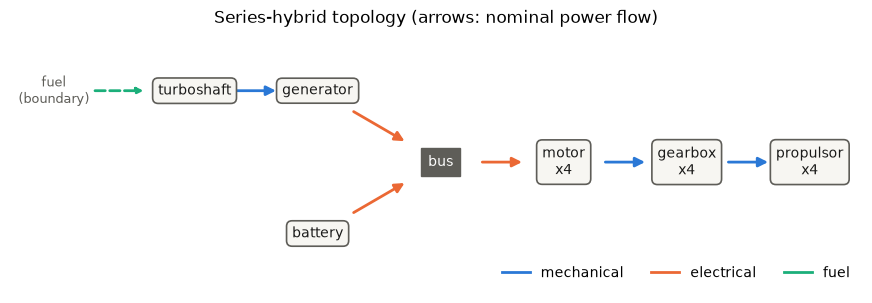

In [7]:
# Network diagram drawn from the topology object itself: positions are layout only.
layout = {"turboshaft": (0, 1), "generator": (1.4, 1), "battery": (1.4, -0.2), "bus": (2.8, 0.4),
          "motor": (4.2, 0.4), "gearbox": (5.6, 0.4), "propulsor": (7.0, 0.4)}
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.set_axis_off()
for name, (x, y) in layout.items():
    label = name if name not in hybrid.instances or hybrid.instances[name].count == 1 \
        else f"{name}\nx{hybrid.instances[name].count}"
    box = dict(boxstyle="round,pad=0.4", fc="#f7f6f2", ec="#5e5d58", lw=1.2) if name != "bus" \
        else dict(boxstyle="square,pad=0.5", fc="#5e5d58", ec="#5e5d58")
    ax.text(x, y, label, ha="center", va="center", fontsize=10, bbox=box,
            color="#ffffff" if name == "bus" else "#1a1a19", zorder=3)
for connection in hybrid.connections:
    source = connection.source.partition(".")[0]
    target = connection.target.partition(".")[0]
    port = hybrid.get_port(connection.source)
    domain = port.domain
    if port.direction is Direction.IN:
        # A consumer on a bus draws power from it: draw the arrow bus -> port.
        source, target = target, source
    ax.add_patch(FancyArrowPatch(layout[source], layout[target], arrowstyle="-|>", mutation_scale=14,
                                 color=domain_colors[domain], lw=2, shrinkA=30, shrinkB=30, zorder=2))
ax.annotate("fuel\n(boundary)", xy=(-0.55, 1), xytext=(-1.6, 1), va="center", ha="center", fontsize=9, color="#5e5d58",
            arrowprops=dict(arrowstyle="-|>", color=domain_colors[Domain.FUEL], lw=2, ls="--"))
for domain, color in domain_colors.items():
    ax.plot([], [], color=color, lw=2, label=domain.value)
ax.legend(loc="lower right", frameon=False, ncol=3)
ax.set(xlim=(-2.1, 7.6), ylim=(-0.7, 1.5), title="Series-hybrid topology (arrows: nominal power flow)")
plt.show()

## 5. Reference case 1: Tier 1 reproduction

`examples/series_hybrid_point.py` builds the same hover point as
`examples/series_hybrid_point_explicit.py` (5000 N, 20 % battery share of motor
electrical input) but takes every connection equation from
`connection_residuals`. Compared with the explicit version it adds coupling
variables at the connections (turboshaft torque, rotor speed/torque, bus voltage)
so the shaft and bus residuals are genuinely active. Plan acceptance: agreement
within 1e-6 relative.

In [8]:
explicit = solve_reference_point()
single = solve_topology_point(count_rotors=1)
print(f"{'quantity':<18}{'explicit (Tier 1)':>20}{'topology (Tier 2)':>20}{'rel. diff':>12}")
for field in ("thrust_N", "shaft_power_W", "battery_power_W", "fuel_flow_kg_s"):
    a, b = getattr(explicit, field), getattr(single, field)
    print(f"{field:<18}{a:>20.8g}{b:>20.8g}{abs(b - a) / abs(a):>12.1e}")
    check(f"reference 1: {field} reproduces Tier 1 within 1e-6", close(b, a, rel=1e-6))
print(f"\nmax |connection residual| = {single.max_abs_connection_residual:.2e}")
check("reference 1: all connection residuals ~ 0", single.max_abs_connection_residual < 1e-6)
check("reference 1: bus power balance ~ 0 W", abs(single.bus_power_residual_W) < 1e-4)
check("reference 1: rotor momentum residual ~ 0 W", abs(single.rotor_power_residual_W) < 1e-4)
check("reference 1: 89.286 kW rotor shaft power", close(single.shaft_power_W, 89285.745, rel=1e-5))
check("reference 1: 18.653 kW battery power", close(single.battery_power_W, 18653.249, rel=1e-5))
check("reference 1: 0.005852 kg/s fuel flow", close(single.fuel_flow_kg_s, 0.0058516, rel=1e-4))

quantity             explicit (Tier 1)   topology (Tier 2)   rel. diff
thrust_N                          5000                5000     0.0e+00
PASS  reference 1: thrust_N reproduces Tier 1 within 1e-6
shaft_power_W                89285.745           89285.745     1.2e-13
PASS  reference 1: shaft_power_W reproduces Tier 1 within 1e-6
battery_power_W              18653.249           18653.249     3.0e-13
PASS  reference 1: battery_power_W reproduces Tier 1 within 1e-6
fuel_flow_kg_s            0.0058515697        0.0058515697     3.4e-13
PASS  reference 1: fuel_flow_kg_s reproduces Tier 1 within 1e-6

max |connection residual| = 8.11e-11
PASS  reference 1: all connection residuals ~ 0
PASS  reference 1: bus power balance ~ 0 W
PASS  reference 1: rotor momentum residual ~ 0 W
PASS  reference 1: 89.286 kW rotor shaft power
PASS  reference 1: 18.653 kW battery power
PASS  reference 1: 0.005852 kg/s fuel flow


## 6. Reference case 2: four symmetric rotor strings

Four motor/gearbox/rotor strings share one bus at 4 x 5000 N. Symmetric
multiplicity means all four share one set of port values; only the bus current
law sees the factor 4. The shared battery is four reference packs in parallel
(resistance / 4) so the bus voltage, and therefore per-motor current, matches the
single-rotor case. Generator and turboshaft ratings scale with $n$ but their loss
and efficiency parameters do not.

In [9]:
quad = solve_topology_point(count_rotors=4)
print(f"{'quantity':<24}{'n = 1':>14}{'n = 4':>14}{'ratio':>8}")
for field in ("thrust_N", "shaft_power_W", "current_motor_A", "voltage_bus_V",
              "current_motors_total_A", "battery_power_W", "fuel_flow_kg_s"):
    a, b = getattr(single, field), getattr(quad, field)
    print(f"{field:<24}{a:>14.6g}{b:>14.6g}{b / a:>8.4f}")
check("reference 2: total thrust 20 kN", close(quad.thrust_N, 20000, rel=1e-6))
check("reference 2: per-rotor shaft power unchanged", close(quad.shaft_power_W, single.shaft_power_W, rel=1e-6))
check("reference 2: per-motor current unchanged", close(quad.current_motor_A, single.current_motor_A, rel=1e-6))
check("reference 2: bus voltage unchanged", close(quad.voltage_bus_V, single.voltage_bus_V, rel=1e-6))
check("reference 2: total motor current 4x", close(quad.current_motors_total_A, 4 * single.current_motors_total_A, rel=1e-6))
check("reference 2: battery power 4x (20 % of 4x demand)", close(quad.battery_power_W, 4 * single.battery_power_W, rel=1e-6))
check("reference 2: fuel flow > 4x (one generator, quadratic losses)", quad.fuel_flow_kg_s > 4 * single.fuel_flow_kg_s)
check("reference 2: connection residuals ~ 0", quad.max_abs_connection_residual < 1e-6)

quantity                         n = 1         n = 4   ratio
thrust_N                          5000         20000  4.0000
shaft_power_W                  89285.7       89285.7  1.0000
current_motor_A                116.753       116.753  1.0000
voltage_bus_V                  798.832       798.832  1.0000
current_motors_total_A         116.753       467.013  4.0000
battery_power_W                18653.2         74613  4.0000
fuel_flow_kg_s              0.00585157     0.0240835  4.1157
PASS  reference 2: total thrust 20 kN
PASS  reference 2: per-rotor shaft power unchanged
PASS  reference 2: per-motor current unchanged
PASS  reference 2: bus voltage unchanged
PASS  reference 2: total motor current 4x
PASS  reference 2: battery power 4x (20 % of 4x demand)
PASS  reference 2: fuel flow > 4x (one generator, quadratic losses)
PASS  reference 2: connection residuals ~ 0


### Multiplicity sweep

Same point for $n = 1 \dots 6$, each quantity indexed to its $n = 1$ value so all
share one axis. Per-rotor quantities stay at 1; total motor current equals $n$
exactly; fuel flow rises faster than $n$ because the single generator's
quadratic torque loss grows with $n^2$.

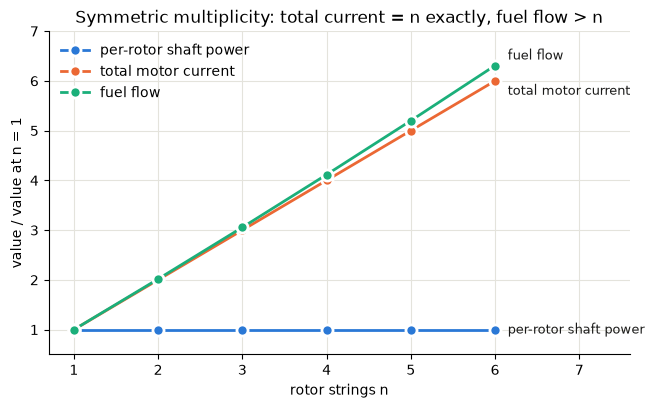

PASS  sweep: per-rotor shaft power constant in n
PASS  sweep: total motor current exactly proportional to n
PASS  sweep: fuel flow superlinear in n
PASS  sweep: every point closes its connection residuals


In [10]:
counts = list(range(1, 7))
sweep = [solve_topology_point(count_rotors=n) for n in counts]
series = {
    "per-rotor shaft power": [s.shaft_power_W / sweep[0].shaft_power_W for s in sweep],
    "total motor current": [s.current_motors_total_A / sweep[0].current_motors_total_A for s in sweep],
    "fuel flow": [s.fuel_flow_kg_s / sweep[0].fuel_flow_kg_s for s in sweep],
}
colors = ["#2a78d6", "#eb6834", "#1baf7a"]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for (label, values), color in zip(series.items(), colors):
    ax.plot(counts, values, color=color, lw=2, marker="o", ms=8, mec="white", mew=2, label=label, zorder=3)
    ax.text(6.15, values[-1] + (0.2 if label == "fuel flow" else -0.2 if label == "total motor current" else 0),
            label, color="#1a1a19", va="center", fontsize=9)
ax.set(xlabel="rotor strings n", ylabel="value / value at n = 1", xlim=(0.7, 7.6), ylim=(0.5, 7),
       title="Symmetric multiplicity: total current = n exactly, fuel flow > n")
ax.legend(frameon=False, loc="upper left")
plt.show()

check("sweep: per-rotor shaft power constant in n", all(close(v, 1, rel=1e-6) for v in series["per-rotor shaft power"]))
check("sweep: total motor current exactly proportional to n",
      all(close(v, n, rel=1e-6) for v, n in zip(series["total motor current"], counts)))
check("sweep: fuel flow superlinear in n", all(v > n for v, n in zip(series["fuel flow"][1:], counts[1:])))
check("sweep: every point closes its connection residuals", all(s.max_abs_connection_residual < 1e-6 for s in sweep))

## 7. Architectural boundaries

Static checks that the topology layer stays a description and dependencies flow
downward (AGENTS rules 3 and 12):

* `core/` imports nothing from `powertrain/` or any higher layer.
* `core/topology.py` imports no AeroSandbox or CasADi and its code references no
  `Opti`, `variable`, `parameter`, `subject_to`, `minimize` or `solve`: it cannot
  own variables, constraints or solves.
* Tier 1 component modules do not import `core/` or the topology layer.

In [11]:
def imports_of(path):
    tree = ast.parse(path.read_text(encoding="utf-8"))
    names = {a.name for n in ast.walk(tree) if isinstance(n, ast.Import) for a in n.names}
    names |= {("." * n.level) + (n.module or "") for n in ast.walk(tree) if isinstance(n, ast.ImportFrom)}
    return names


package = repo_root / "src/aircraft_closure"
for path in sorted((package / "core").glob("*.py")):
    imports = imports_of(path)
    print(f"{path.name:<12} {sorted(imports)}")
    check(f"boundaries: core/{path.name} imports no higher layer",
          not any("powertrain" in name for name in imports))
# Inspect code, not prose: docstrings may legitimately mention Opti.
topology_tree = ast.parse((package / "core/topology.py").read_text(encoding="utf-8"))
optimization_names = {"Opti", "variable", "subject_to", "solve", "minimize", "parameter"}
used_names = {n.id for n in ast.walk(topology_tree) if isinstance(n, ast.Name)}
used_names |= {n.attr for n in ast.walk(topology_tree) if isinstance(n, ast.Attribute)}
print("optimization names used in core/topology.py:", sorted(used_names & optimization_names))
check("boundaries: core/topology.py imports no AeroSandbox/CasADi",
      not any(name.split(".")[0] in ("aerosandbox", "casadi") for name in imports_of(package / "core/topology.py")))
check("boundaries: core/topology.py creates no variables, constraints or solves",
      not used_names & optimization_names)
for path in sorted((package / "powertrain/components").glob("*.py")):
    check(f"boundaries: components/{path.name} does not import the topology layer",
          not any("core" in name or "topolog" in name or name.endswith("ports") for name in imports_of(path)))

__init__.py  []
PASS  boundaries: core/__init__.py imports no higher layer
margins.py   ['dataclasses', 'typing']
PASS  boundaries: core/margins.py imports no higher layer
ports.py     ['dataclasses', 'enum', 'typing']
PASS  boundaries: core/ports.py imports no higher layer
topology.py  ['.ports', 'dataclasses', 'typing']
PASS  boundaries: core/topology.py imports no higher layer
optimization names used in core/topology.py: []
PASS  boundaries: core/topology.py imports no AeroSandbox/CasADi
PASS  boundaries: core/topology.py creates no variables, constraints or solves
PASS  boundaries: components/__init__.py does not import the topology layer
PASS  boundaries: components/battery.py does not import the topology layer
PASS  boundaries: components/gearbox.py does not import the topology layer
PASS  boundaries: components/generator.py does not import the topology layer
PASS  boundaries: components/motor.py does not import the topology layer
PASS  boundaries: components/propulsor.py does no

## 8. Summary and unit test suite

In [12]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

72 / 72 notebook checks passed


In [13]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 77 tests in 0.177s

OK


C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)
